# SMOTE - Balancing Customer Churn Dataset   Telco Customer Churn Prediction
The Telco Customer Churn Dataset contains historical data of telecom customers. This notebook applies SMOTE (Synthetic Minority Over-sampling Technique) to balance the imbalanced churn dataset, making it suitable for machine learning model training.

## 1. Import Required Libraries

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from collections import Counter

# Display settings
pd.set_option('display.max_columns', None)
print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load the Preprocessed Dataset

In [2]:
# Load the preprocessed dataset
df = pd.read_csv('../mid-data/preprocessed.csv')

print("Dataset loaded successfully!")
print(f"\nDataset shape: {df.shape}")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print("\nFirst few rows:")
print(df.head())

Dataset loaded successfully!

Dataset shape: (7043, 31)
Number of rows: 7043
Number of columns: 31

First few rows:
   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       0              0        1           0       1             0   
1       1              0        0           0      34             1   
2       1              0        0           0       2             1   
3       1              0        0           0      45             0   
4       0              0        0           0       2             1   

   PaperlessBilling  MonthlyCharges  TotalCharges  Churn  MultipleLines_Yes  \
0                 1           29.85         29.85      0                  0   
1                 0           56.95       1889.50      0                  0   
2                 1           53.85        108.15      1                  0   
3                 0           42.30       1840.75      0                  0   
4                 1           70.70        151.65      1      

## 3. Explore Class Distribution (Before SMOTE)

Churn Distribution (BEFORE SMOTE):
Churn
0    5174
1    1869
Name: count, dtype: int64

Percentage Distribution:
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64

Note: Class imbalance is clearly visible - minority class (Churn=1) is underrepresented.


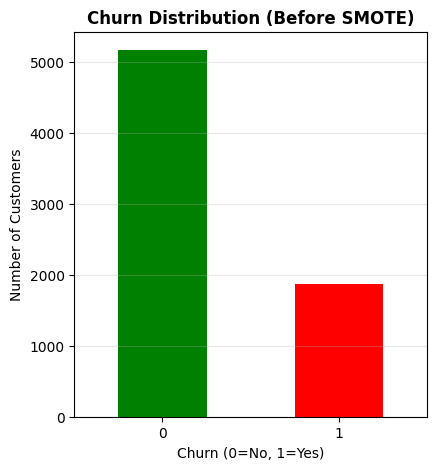

In [7]:
# Check the target variable (Churn column)
print("Churn Distribution (BEFORE SMOTE):")
print("=" * 50)
churn_counts = df['Churn'].value_counts()
print(churn_counts)
print(f"\nPercentage Distribution:")
print(df['Churn'].value_counts(normalize=True) * 100)

# Visualize class imbalance
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
df['Churn'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Churn Distribution (Before SMOTE)', fontsize=12, fontweight='bold')
plt.xlabel('Churn (0=No, 1=Yes)')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

print("\nNote: Class imbalance is clearly visible - minority class (Churn=1) is underrepresented.")

## 4. Apply SMOTE to Balance the Dataset

### What is SMOTE?
SMOTE (Synthetic Minority Over-sampling Technique) creates synthetic samples of the minority class to balance the dataset. This improves model performance by providing equal weight to both classes during training.

In [4]:
# Separate features (X) and target (y)
X = df.drop('Churn', axis=1)  # Features: all columns except Churn
y = df['Churn']               # Target: Churn column

print("Features shape:", X.shape)
print("Target shape:", y.shape)

# Apply SMOTE
print("\n" + "=" * 50)
print("Applying SMOTE...")
print("=" * 50)

smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)

print("SMOTE applied successfully!")
print(f"\nOriginal dataset shape: {X.shape}")
print(f"SMOTE balanced dataset shape: {X_smote.shape}")

Features shape: (7043, 30)
Target shape: (7043,)

Applying SMOTE...
SMOTE applied successfully!

Original dataset shape: (7043, 30)
SMOTE balanced dataset shape: (10348, 30)



CLASS DISTRIBUTION COMPARISON

BEFORE SMOTE:
Counter({0: 5174, 1: 1869})

AFTER SMOTE:
Counter({0: 5174, 1: 5174})


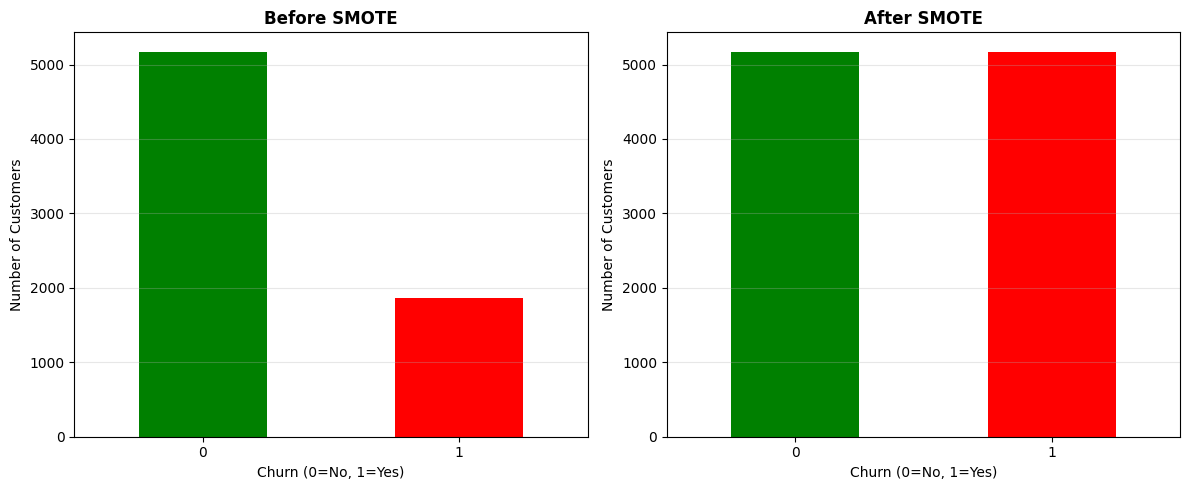


✓ Dataset is now perfectly balanced!


In [8]:
# Compare class distribution before and after SMOTE
print("\n" + "=" * 50)
print("CLASS DISTRIBUTION COMPARISON")
print("=" * 50)

print("\nBEFORE SMOTE:")
print(Counter(y))

print("\nAFTER SMOTE:")
print(Counter(y_smote))

# Visualize the comparison
plt.figure(figsize=(12, 5))

# Before SMOTE
plt.subplot(1, 2, 1)
pd.Series(y).value_counts().sort_index().plot(kind='bar', color=['green', 'red'])
plt.title('Before SMOTE', fontsize=12, fontweight='bold')
plt.xlabel('Churn (0=No, 1=Yes)')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

# After SMOTE
plt.subplot(1, 2, 2)
pd.Series(y_smote).value_counts().sort_index().plot(kind='bar', color=['green', 'red'])
plt.title('After SMOTE', fontsize=12, fontweight='bold')
plt.xlabel('Churn (0=No, 1=Yes)')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Dataset is now perfectly balanced!")

## 5. Save the SMOTE Balanced Dataset

In [6]:
# Convert SMOTE output back to DataFrame
df_smote = pd.DataFrame(X_smote, columns=X.columns)
df_smote['Churn'] = y_smote.values

print("SMOTE balanced dataset created!")
print(f"Dataset shape: {df_smote.shape}")
print(f"\nFirst few rows:")
print(df_smote.head())

# Save to Dataset folder
output_path = '../Dataset/smote_balanced.csv'
df_smote.to_csv(output_path, index=False)

print("\n" + "=" * 50)
print("✓ SMOTE dataset saved successfully!")
print("=" * 50)
print(f"File location: {output_path}")
print(f"Total records: {len(df_smote)}")
print(f"Features: {df_smote.shape[1]}")

SMOTE balanced dataset created!
Dataset shape: (10348, 31)

First few rows:
   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       0              0        1           0       1             0   
1       1              0        0           0      34             1   
2       1              0        0           0       2             1   
3       1              0        0           0      45             0   
4       0              0        0           0       2             1   

   PaperlessBilling  MonthlyCharges  TotalCharges  MultipleLines_Yes  \
0                 1           29.85         29.85                  0   
1                 0           56.95       1889.50                  0   
2                 1           53.85        108.15                  0   
3                 0           42.30       1840.75                  0   
4                 1           70.70        151.65                  0   

   MultipleLines_NoService  OnlineSecurity_Yes  OnlineSecurity_N

## Summary

**SMOTE Application Summary:**
- ✓ Loaded preprocessed Telco Customer Churn dataset
- ✓ Analyzed class imbalance (imbalanced churn vs non-churn customers)
- ✓ Applied SMOTE to create synthetic samples of minority class
- ✓ Balanced the dataset with equal number of both classes
- ✓ Saved the balanced dataset as `smote_balanced.csv` in the Dataset folder

**Benefits of SMOTE:**
1. **Better Model Performance**: Prevents the model from being biased toward the majority class
2. **Improved Metrics**: Provides more reliable precision, recall, and F1-score
3. **Synthetic Data**: Creates realistic samples using existing data rather than simple duplication
4. **Ready for Training**: The balanced dataset is now suitable for building and training machine learning models

The SMOTE-balanced dataset is ready for model training and evaluation! 🎯